Mounted at /content/drive
--- Cargando y limpiando datos ---

🚀 Iniciando Grid Search (8 modelos) en cuda...
⚖️ Criterio Único de Optimización y Selección: MAE en Euros (tras des-log) sobre Validación

[1/8] Entrenando: Periodic_d128_n1
  -> Val MAE Euros Final: 73,280€
[2/8] Entrenando: Periodic_d128_n2
  -> Val MAE Euros Final: 100,448€
[3/8] Entrenando: Periodic_d256_n1
  -> Val MAE Euros Final: 92,393€
[4/8] Entrenando: Periodic_d256_n2
  -> Val MAE Euros Final: 94,607€
[5/8] Entrenando: PLE_d128_n1
  -> Val MAE Euros Final: 57,217€
[6/8] Entrenando: PLE_d128_n2
  -> Val MAE Euros Final: 229,571€
[7/8] Entrenando: PLE_d256_n1
  -> Val MAE Euros Final: 61,530€
[8/8] Entrenando: PLE_d256_n2
  -> Val MAE Euros Final: 182,319€

👑 GANADOR DEL GRID: PLE_d128_n1 (Val MAE: 57,217€)
Desprecintando el conjunto de Test para la evaluación final...

--- Resultados Oficiales en TEST (Importe Directo) ---
R2 Score (Euros): -0.0412
MAE en Euros: 81,394.22 €
MdAPE: 5.7416 %


,Modelo,Embeddings,d_block,n_blocks,Val_MAE_Euros
0,PLE_d128_n1,PLE,128,1,57216.734767
1,PLE_d256_n1,PLE,256,1,61530.102057
2,Periodic_d128_n1,Periodic,128,1,73280.098516
3,Periodic_d256_n1,Periodic,256,1,92393.288841
4,Periodic_d256_n2,Periodic,256,2,94607.297092
5,Periodic_d128_n2,Periodic,128,2,100447.917201
6,PLE_d256_n2,PLE,256,2,182319.298693
7,PLE_d128_n2,PLE,128,2,229571.224639


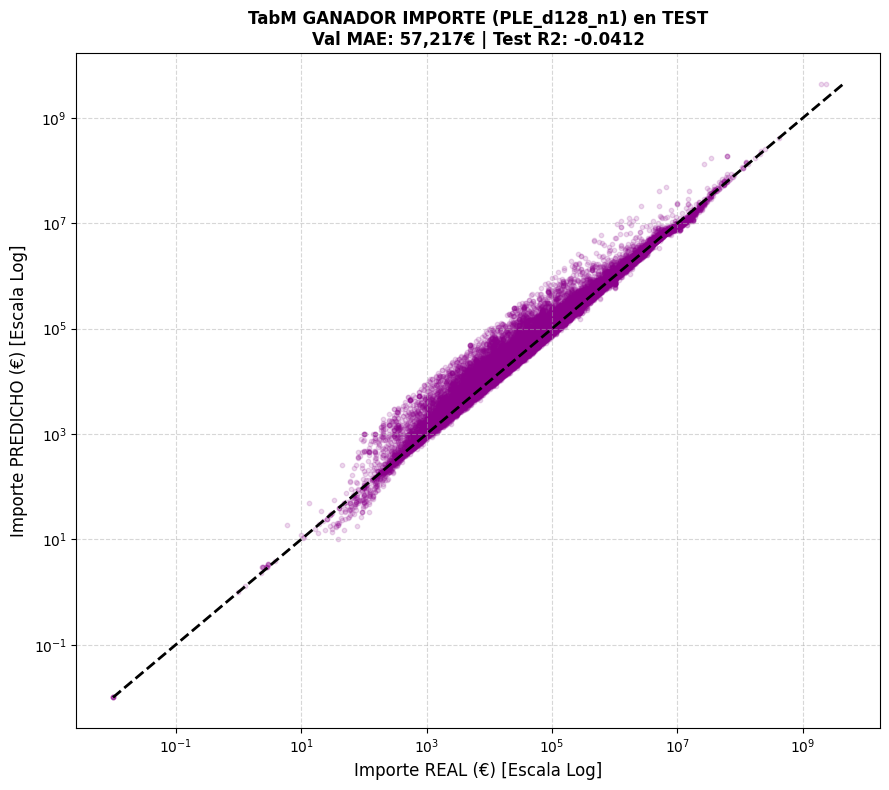

In [ ]:
# ==============================================================================
# SÚPER CELDA: GRID SEARCH TABM PARA IMPORTE DIRECTO (Log-Transform)
# ==============================================================================
!pip install tabm rtdl_num_embeddings -q

import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from tabm import TabM
import rtdl_num_embeddings
from google.colab import drive
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, r2_score
import random
import os
import gc
import shutil
import warnings
from IPython.display import display

# --- 0. Semillas y Limpieza ---
warnings.filterwarnings('ignore')

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)

# --- 1. Montaje y Rutas ---
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')
CARPETA_TFG = Path("/content/drive/MyDrive/TFG_Final_Contratacion")
# Cambiamos la carpeta de salida para no machacar los gráficos de la Baja
OUTPUT_DIR_TABM = CARPETA_TFG / "salida_graficos_TabM_IMPORTE_GridSearch"
OUTPUT_DIR_TABM.mkdir(exist_ok=True)

# EL TARGET AHORA ES EL IMPORTE
TARGET = 'lote_importe_adjudicacion_sin_impuestos'
PRESUPUESTO = 'lote_presupuesto_base_sin_impuestos'
VALOR_ESTIMADO = 'valor_estimado_imputado'

def limpiar_df_estricto_importe(df):
    if 'es_exito' in df.columns: df = df[df['es_exito'] == 1].copy()
    if PRESUPUESTO in df.columns and VALOR_ESTIMADO in df.columns:
        df = df[df[TARGET] >= 0].copy() # Importes no negativos
        df = df[df[TARGET] <= df[PRESUPUESTO]].copy() # Tope normativo: adjudicación <= presupuesto
        df = df[df[PRESUPUESTO] <= df[VALOR_ESTIMADO]].copy()
        df = df[df[VALOR_ESTIMADO] <= (df[PRESUPUESTO] * 10)].copy()
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(subset=[TARGET, PRESUPUESTO], inplace=True)
    return df

print("--- Cargando y limpiando datos ---")
train_df = limpiar_df_estricto_importe(pd.read_parquet(CARPETA_TFG / "train_procesado_v2_limpio.parquet"))
val_df_intacto   = limpiar_df_estricto_importe(pd.read_parquet(CARPETA_TFG / "val_procesado_v2_limpio.parquet"))
test_df_intacto = limpiar_df_estricto_importe(pd.read_parquet(CARPETA_TFG / "test_procesado_v2_limpio.parquet"))

val_df = val_df_intacto.copy()
test_df = test_df_intacto.copy()

# AÑADIMOS 'pct_baja' A DROP_COLS PARA EVITAR FUGA DE INFORMACIÓN (Data Leakage)
DROP_COLS = ['_id', 'id', 'fecha_primera_publicacion', 'objeto', 'lote_objeto', 'organo_contratacion', 'lote_adjudicatario', 'lote_resultado', 'cpv_final_imputado', 'cif_normalizado', 'lote_importe_adjudicacion_con_impuestos', 'es_exito', 'es_sobrecoste', 'lote_numero_ofertas_recibidas', 'presupuesto_medio_hist', 'descuento_promedio', 'lote_precio_oferta_mas_alta', 'lote_precio_oferta_mas_baja', 'duracion_proceso_dias', 'es_anomalia_temporal', 'pct_baja']

for df in [train_df, val_df, test_df]:
    df.drop(columns=[c for c in DROP_COLS if c in df.columns], inplace=True, errors='ignore')

features = [col for col in train_df.columns if col != TARGET]
categorical_cols = train_df[features].select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
numerical_cols = train_df[features].select_dtypes(exclude=['object', 'category', 'bool']).columns.tolist()

# --- 2. Preprocesamiento ---
scaler_X = StandardScaler()
X_train_num = scaler_X.fit_transform(train_df[numerical_cols]).astype(np.float32)
X_val_num   = scaler_X.transform(val_df[numerical_cols]).astype(np.float32)
X_test_num  = scaler_X.transform(test_df[numerical_cols]).astype(np.float32)

cat_cardinalities = []
if categorical_cols:
    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_train_cat = encoder.fit_transform(train_df[categorical_cols]).astype(np.int64)
    X_val_cat   = encoder.transform(val_df[categorical_cols]).astype(np.int64)
    X_test_cat  = encoder.transform(test_df[categorical_cols]).astype(np.int64)
    for i, col in enumerate(categorical_cols):
        c_len = len(encoder.categories_[i])
        cat_cardinalities.append(c_len + 1)
        X_train_cat[:, i] = np.where(X_train_cat[:, i] == -1, c_len, X_train_cat[:, i])
        X_val_cat[:, i]   = np.where(X_val_cat[:, i] == -1, c_len, X_val_cat[:, i])
        X_test_cat[:, i]  = np.where(X_test_cat[:, i] == -1, c_len, X_test_cat[:, i])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bins = rtdl_num_embeddings.compute_bins(torch.tensor(X_train_num, dtype=torch.float32))

# TRANSFORMACIÓN LOGARÍTMICA DEL TARGET PARA ENTRENAR LA RED NEURONAL
y_train = torch.tensor(np.log1p(train_df[TARGET].values), dtype=torch.float32)

# --- 3. DEFINICIÓN DEL GRID (VERSIÓN LIGERA PARA IMPORTE) ---
configuraciones = []
for emb in ["Periodic", "PLE"]:
    # 📉 Reducimos las neuronas: quitamos 512 (muy pesado) y metemos 128 (muy ligero)
    for d in [128, 256]:
        # 📉 Reducimos las capas: quitamos 3 (muy profundo) y metemos 1 (súper rápido)
        for n in [1, 2]:
            configuraciones.append({"emb": emb, "d_block": d, "n_blocks": n})

resultados_grid = []
mejor_val_mae_euros_global = np.inf
nombre_ganador = ""
ruta_ganador_final = CARPETA_TFG / "TabM_GANADOR_IMPORTE.pth"

epochs = 40
batch_size = 128
patience = 5

print(f"\n🚀 Iniciando Grid Search ({len(configuraciones)} modelos) en {device}...")
print(f"⚖️ Criterio Único de Optimización y Selección: MAE en Euros (tras des-log) sobre Validación\n")

val_presupuestos = val_df_intacto[PRESUPUESTO].values
val_importes_reales = val_df_intacto[TARGET].values

for idx, conf in enumerate(configuraciones):
    nombre_exp = f"{conf['emb']}_d{conf['d_block']}_n{conf['n_blocks']}"
    print(f"[{idx+1}/{len(configuraciones)}] Entrenando: {nombre_exp}")

    set_seed(42)

    if conf['emb'] == "PLE":
        num_embeddings = rtdl_num_embeddings.PiecewiseLinearEmbeddings(bins=bins, d_embedding=16, activation=False, version="B")
    else:
        num_embeddings = rtdl_num_embeddings.PeriodicEmbeddings(n_features=len(numerical_cols), d_embedding=16, lite=False)

    model = TabM.make(
        n_num_features=len(numerical_cols),
        num_embeddings=num_embeddings,
        cat_cardinalities=cat_cardinalities if categorical_cols else None,
        d_out=1,
        k=32,
        d_block=conf['d_block'],
        n_blocks=conf['n_blocks']
    ).to(device)

    optimizer = optim.AdamW(model.parameters(), lr=0.002, weight_decay=0.0003)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
    loss_fn = nn.L1Loss()

    best_val_mae_euros_epoch = np.inf
    trigger_times = 0
    ruta_guardado = CARPETA_TFG / f"TabM_TMP_IMPORTE.pth"

    for epoch in range(epochs):
        model.train()
        indices = np.random.permutation(len(X_train_num))
        for i in range(0, len(X_train_num), batch_size):
            idx_batch = indices[i:i+batch_size]
            x_n = torch.tensor(X_train_num[idx_batch], dtype=torch.float32).to(device)
            y_b = y_train[idx_batch].to(device)
            optimizer.zero_grad()

            if categorical_cols:
                x_c = torch.tensor(X_train_cat[idx_batch], dtype=torch.long).to(device)
                preds = model(x_n, x_c).squeeze(-1)
            else:
                preds = model(x_n).squeeze(-1)

            loss = loss_fn(preds, y_b.unsqueeze(1).expand_as(preds))
            loss.backward()
            optimizer.step()

        model.eval()
        val_preds_epoch = []
        with torch.no_grad():
            for j in range(0, len(X_val_num), batch_size):
                x_v_n = torch.tensor(X_val_num[j:j+batch_size], dtype=torch.float32).to(device)
                if categorical_cols:
                    x_v_c = torch.tensor(X_val_cat[j:j+batch_size], dtype=torch.long).to(device)
                    v_out = model(x_v_n, x_v_c).squeeze(-1).mean(dim=1)
                else:
                    v_out = model(x_v_n).squeeze(-1).mean(dim=1)
                val_preds_epoch.extend(v_out.cpu().numpy())

        # DESTRANSFORMACIÓN LOGARÍTMICA (expm1) Y TOPE DE NEGOCIO (<= Presupuesto)
        val_preds_log = np.array(val_preds_epoch)
        val_preds_euros_raw = np.expm1(val_preds_log)
        importe_predicho_val = np.clip(val_preds_euros_raw, 0.0, val_presupuestos)

        val_mae_euros_actual = np.abs(val_importes_reales - importe_predicho_val).mean()
        scheduler.step(val_mae_euros_actual)

        if val_mae_euros_actual < best_val_mae_euros_epoch:
            best_val_mae_euros_epoch = val_mae_euros_actual
            torch.save(model.state_dict(), ruta_guardado)
            trigger_times = 0
        else:
            trigger_times += 1
            if trigger_times >= patience:
                break

    print(f"  -> Val MAE Euros Final: {best_val_mae_euros_epoch:,.0f}€")

    resultados_grid.append({
        "Modelo": nombre_exp,
        "Embeddings": conf['emb'],
        "d_block": conf['d_block'],
        "n_blocks": conf['n_blocks'],
        "Val_MAE_Euros": best_val_mae_euros_epoch
    })

    if best_val_mae_euros_epoch < mejor_val_mae_euros_global:
        mejor_val_mae_euros_global = best_val_mae_euros_epoch
        nombre_ganador = nombre_exp
        shutil.copy(ruta_guardado, ruta_ganador_final)

    del model, optimizer, scheduler, num_embeddings
    torch.cuda.empty_cache()
    gc.collect()
    if os.path.exists(ruta_guardado):
        os.remove(ruta_guardado)

# --- 4. EXPOSICIÓN AL CONJUNTO DE TEST (SÓLO EL GANADOR) ---
print("\n" + "="*60)
print(f"👑 GANADOR DEL GRID: {nombre_ganador} (Val MAE: {mejor_val_mae_euros_global:,.0f}€)")
print("Desprecintando el conjunto de Test para la evaluación final...")
print("="*60)

emb_ganador = nombre_ganador.split('_')[0]
d_ganador = int(nombre_ganador.split('_d')[1].split('_')[0])
n_ganador = int(nombre_ganador.split('_n')[1])

if emb_ganador == "PLE":
    num_embeddings_final = rtdl_num_embeddings.PiecewiseLinearEmbeddings(bins=bins, d_embedding=16, activation=False, version="B")
else:
    num_embeddings_final = rtdl_num_embeddings.PeriodicEmbeddings(n_features=len(numerical_cols), d_embedding=16, lite=False)

model_ganador = TabM.make(
    n_num_features=len(numerical_cols),
    num_embeddings=num_embeddings_final,
    cat_cardinalities=cat_cardinalities if categorical_cols else None,
    d_out=1,
    k=32,
    d_block=d_ganador,
    n_blocks=n_ganador
).to(device)

model_ganador.load_state_dict(torch.load(ruta_ganador_final))
model_ganador.eval()

test_preds = []
with torch.no_grad():
    for i in range(0, len(X_test_num), batch_size):
        x_t_n = torch.tensor(X_test_num[i:i+batch_size], dtype=torch.float32).to(device)
        if categorical_cols:
            x_t_c = torch.tensor(X_test_cat[i:i+batch_size], dtype=torch.long).to(device)
            t_out = model_ganador(x_t_n, x_t_c).squeeze(-1).mean(dim=1)
        else:
            t_out = model_ganador(x_t_n).squeeze(-1).mean(dim=1)
        test_preds.extend(t_out.cpu().numpy())

# DESTRANSFORMACIÓN EN TEST Y CÁLCULO DE MÉTRICAS
test_presupuestos = test_df_intacto[PRESUPUESTO].values
test_preds_log = np.array(test_preds)
test_preds_euros_raw = np.expm1(test_preds_log)
importe_predicho_test = np.clip(test_preds_euros_raw, 0.0, test_presupuestos) # Tope normativo

test_y_reales = test_df_intacto[TARGET].values

# Métricas en Euros
test_r2 = r2_score(test_y_reales, importe_predicho_test)
test_mae_euros = mean_absolute_error(test_y_reales, importe_predicho_test)

# MdAPE (Error Relativo Mediano)
mask = test_y_reales != 0
test_mdape = np.median(np.abs((test_y_reales[mask] - importe_predicho_test[mask]) / test_y_reales[mask])) * 100 if np.sum(mask) > 0 else 0

print(f"\n--- Resultados Oficiales en TEST (Importe Directo) ---")
print(f"R2 Score (Euros): {test_r2:.4f}")
print(f"MAE en Euros: {test_mae_euros:,.2f} €")
print(f"MdAPE: {test_mdape:.4f} %")

df_resultados = pd.DataFrame(resultados_grid).sort_values(by="Val_MAE_Euros", ascending=True).reset_index(drop=True)
display(df_resultados)

# --- 5. GRÁFICO FINAL (LOG-LOG SCATTERPLOT) ---
plt.figure(figsize=(9, 8))
plt.scatter(test_y_reales, importe_predicho_test, alpha=0.15, color='darkmagenta', s=10)

# Línea de predicción perfecta
max_val = max(test_y_reales.max(), importe_predicho_test.max())
min_val = min(test_y_reales.min(), importe_predicho_test.min())
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', linewidth=2)

plt.xscale('log')
plt.yscale('log')
plt.title(f'TabM GANADOR IMPORTE ({nombre_ganador}) en TEST\nVal MAE: {mejor_val_mae_euros_global:,.0f}€ | Test R2: {test_r2:.4f}', fontsize=12, fontweight='bold')
plt.xlabel('Importe REAL (€) [Escala Log]', fontsize=12)
plt.ylabel('Importe PREDICHO (€) [Escala Log]', fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(OUTPUT_DIR_TABM / f'Scatter_Importe_Ganador_{nombre_ganador}.png', dpi=300)
plt.show()

df_resultados.to_excel(OUTPUT_DIR_TABM / "Resultados_GridSearch_TabM_IMPORTE.xlsx", index=False)

--- GENERANDO BOXPLOT DE COMPARATIVA APE (IMPORTE DIRECTO) ---


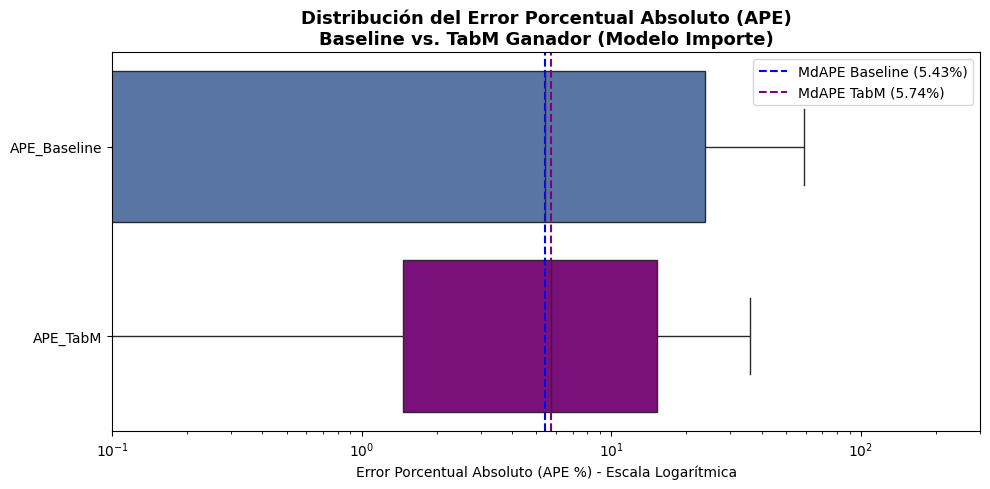

--- GENERANDO SCATTER PLOT EN EUROS (ESCALA LOG) ---


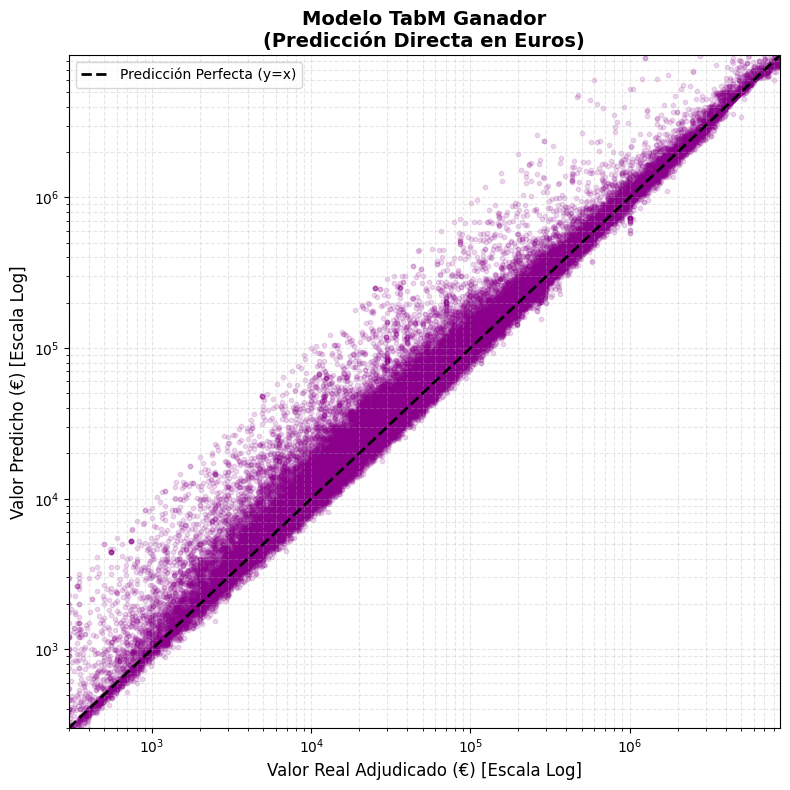

In [ ]:
# ==============================================================================
# GRÁFICO BOXPLOT APE (BASELINE vs TabM GANADOR IMPORTE)
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("--- GENERANDO BOXPLOT DE COMPARATIVA APE (IMPORTE DIRECTO) ---")

try:
    # 1. Ya tenemos las predicciones y reales en euros directamente de la celda anterior
    # importe_predicho_test, test_y_reales y test_presupuestos ya están calculados
    y_pred_tabm_euros = importe_predicho_test

    # El Baseline sigue asumiendo un 0% de baja (Importe = Presupuesto Base)
    y_pred_baseline_euros = test_presupuestos

    # 2. DataFrame de resultados
    df_results = pd.DataFrame({
        'Real': test_y_reales,
        'Prediccion_TabM': y_pred_tabm_euros,
        'Prediccion_Baseline': y_pred_baseline_euros
    })

    # 3. Cálculo del APE (Absolute Percentage Error) para cada contrato
    df_results['APE_TabM'] = 100 * (np.abs(df_results['Real'] - df_results['Prediccion_TabM'])) / df_results['Real']
    df_results['APE_Baseline'] = 100 * (np.abs(df_results['Real'] - df_results['Prediccion_Baseline'])) / df_results['Real']

    # 4. Gráfico Boxplot APE
    plt.figure(figsize=(10, 5))
    sns.boxplot(
        data=df_results[['APE_Baseline', 'APE_TabM']],
        orient='h',
        showfliers=False, # Sin outliers
        palette=['#4C72B0', 'darkmagenta'] # Azul (Baseline) vs Morado (TabM)
    )

    plt.title('Distribución del Error Porcentual Absoluto (APE)\nBaseline vs. TabM Ganador (Modelo Importe)', fontsize=13, fontweight='bold')
    plt.xlabel('Error Porcentual Absoluto (APE %) - Escala Logarítmica')
    plt.gca().set_xscale('log')
    plt.xlim(0.1, 300)

    # Líneas verticales para las medianas (MdAPE)
    median_baseline = df_results['APE_Baseline'].median()
    median_tabm = df_results['APE_TabM'].median()

    plt.axvline(x=median_baseline, color='blue', linestyle='--', label=f"MdAPE Baseline ({median_baseline:.2f}%)")
    plt.axvline(x=median_tabm, color='purple', linestyle='--', label=f"MdAPE TabM ({median_tabm:.2f}%)")

    plt.legend()
    plt.tight_layout()

    # Guardamos con nombre actualizado
    plt.savefig(OUTPUT_DIR_TABM / '1_comparativa_error_boxplot_TabM_Importe.png', dpi=300)
    plt.show()

except Exception as e:
    print(f"Error generando el gráfico: {e}")

# ==============================================================================
# GRÁFICO SCATTER (TabM IMPORTE) - EUROS EN ESCALA LOGARÍTMICA
# ==============================================================================
print("--- GENERANDO SCATTER PLOT EN EUROS (ESCALA LOG) ---")

try:
    # 1. Límites para el zoom usando los datos reales
    min_val_zoom = max(10.0, df_results['Real'].quantile(0.005))
    max_val_zoom = df_results['Real'].quantile(0.995)

    # 2. Dibujamos el gráfico
    plt.figure(figsize=(8, 8))

    # Usamos el color morado característico de TabM
    plt.scatter(df_results['Real'], df_results['Prediccion_TabM'], alpha=0.15, s=10, color='darkmagenta')

    plt.xscale('log')
    plt.yscale('log')
    plt.plot([min_val_zoom, max_val_zoom], [min_val_zoom, max_val_zoom], color='black', linestyle='--', linewidth=2, label='Predicción Perfecta (y=x)')

    # Títulos actualizados para reflejar que es predicción directa
    plt.title("Modelo TabM Ganador\n(Predicción Directa en Euros)", fontsize=14, fontweight='bold')
    plt.xlabel("Valor Real Adjudicado (€) [Escala Log]", fontsize=12)
    plt.ylabel("Valor Predicho (€) [Escala Log]", fontsize=12)

    plt.xlim(min_val_zoom, max_val_zoom)
    plt.ylim(min_val_zoom, max_val_zoom)
    plt.grid(True, which="both", ls="--", alpha=0.3)
    plt.legend()
    plt.tight_layout()

    # Guardamos la imagen
    plt.savefig(OUTPUT_DIR_TABM / '3_scatter_TabM_Importe_Zoom.png', dpi=300)
    plt.show()

except Exception as e:
    print(f"Error generando el gráfico: {e}")

--- 1. Preparando el entorno para Colab y SHAP (IMPORTE) ---
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
--- 2. Cargando y transformando datos desde Drive ---
--- 3. Cargando el modelo ganador desde Drive ---
--- 4. Calculando SHAP (KernelExplainer de Alta Densidad) ---
Calculando SHAP para 1500 muestras (Aprovechando GPU T4)...


  0%|          | 0/1500 [00:00<?, ?it/s]

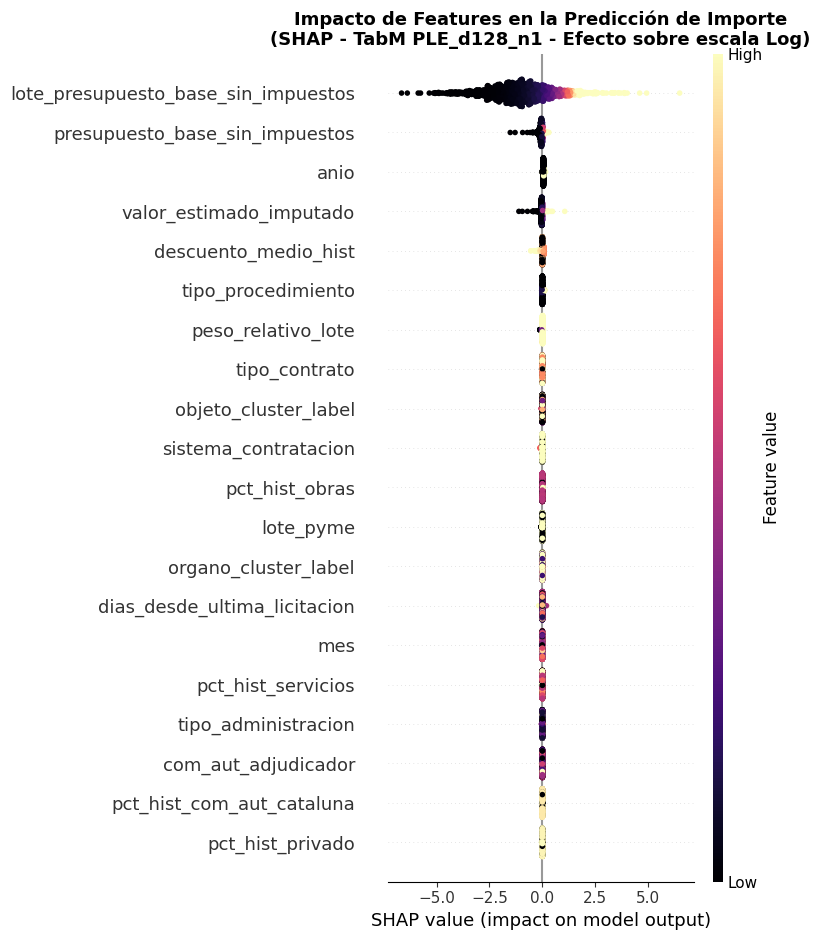

✅ SHAP plot de Importe guardado en: /content/drive/MyDrive/TFG_Final_Contratacion/salida_graficos_TabM_IMPORTE_GridSearch/shap_summary_plot_TabM_PLE_d128_n1_IMPORTE_Kernel.png


In [ ]:
# ==============================================================================
# SCRIPT EXPRESS COLAB: EXPLICABILIDAD SHAP PARA TABM IMPORTE (KernelExplainer)
# ==============================================================================
!pip install tabm rtdl_num_embeddings shap -q

import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from tabm import TabM
import rtdl_num_embeddings
import shap
import matplotlib.pyplot as plt
import warnings
from google.colab import drive

warnings.filterwarnings('ignore')

print("--- 1. Preparando el entorno para Colab y SHAP (IMPORTE) ---")
try:
    drive.mount('/content/drive')
except:
    print("Drive ya montado o error al montar")

CARPETA_TFG = Path("/content/drive/MyDrive/TFG_Final_Contratacion")
OUTPUT_DIR_TABM = CARPETA_TFG / "salida_graficos_TabM_IMPORTE_GridSearch"
OUTPUT_DIR_TABM.mkdir(exist_ok=True)

TARGET = 'lote_importe_adjudicacion_sin_impuestos'
PRESUPUESTO = 'lote_presupuesto_base_sin_impuestos'
VALOR_ESTIMADO = 'valor_estimado_imputado'

def limpiar_df_estricto_importe(df):
    if 'es_exito' in df.columns: df = df[df['es_exito'] == 1].copy()
    if PRESUPUESTO in df.columns and VALOR_ESTIMADO in df.columns:
        df = df[df[TARGET] >= 0].copy()
        df = df[df[TARGET] <= df[PRESUPUESTO]].copy()
        df = df[df[PRESUPUESTO] <= df[VALOR_ESTIMADO]].copy()
        df = df[df[VALOR_ESTIMADO] <= (df[PRESUPUESTO] * 10)].copy()
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(subset=[TARGET, PRESUPUESTO], inplace=True)
    return df

print("--- 2. Cargando y transformando datos desde Drive ---")
train_df = limpiar_df_estricto_importe(pd.read_parquet(CARPETA_TFG / "train_procesado_v2_limpio.parquet"))
test_df = limpiar_df_estricto_importe(pd.read_parquet(CARPETA_TFG / "test_procesado_v2_limpio.parquet"))

# ⚠️ MUY IMPORTANTE: Se añade 'pct_baja' para evitar trampa analítica
DROP_COLS = ['_id', 'id', 'fecha_primera_publicacion', 'objeto', 'lote_objeto', 'organo_contratacion', 'lote_adjudicatario', 'lote_resultado', 'cpv_final_imputado', 'cif_normalizado', 'lote_importe_adjudicacion_con_impuestos', 'es_exito', 'es_sobrecoste', 'lote_numero_ofertas_recibidas', 'presupuesto_medio_hist', 'descuento_promedio', 'lote_precio_oferta_mas_alta', 'lote_precio_oferta_mas_baja', 'duracion_proceso_dias', 'es_anomalia_temporal', 'pct_baja']

train_df.drop(columns=[c for c in DROP_COLS if c in train_df.columns], inplace=True, errors='ignore')
test_df.drop(columns=[c for c in DROP_COLS if c in test_df.columns], inplace=True, errors='ignore')

features = [col for col in train_df.columns if col != TARGET]
categorical_cols = train_df[features].select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
numerical_cols = train_df[features].select_dtypes(exclude=['object', 'category', 'bool']).columns.tolist()

scaler_X = StandardScaler()
X_train_num = scaler_X.fit_transform(train_df[numerical_cols]).astype(np.float32)
X_test_num  = scaler_X.transform(test_df[numerical_cols]).astype(np.float32)

cat_cardinalities = []
if categorical_cols:
    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_train_cat = encoder.fit_transform(train_df[categorical_cols]).astype(np.int64)
    X_test_cat  = encoder.transform(test_df[categorical_cols]).astype(np.int64)
    for i, col in enumerate(categorical_cols):
        c_len = len(encoder.categories_[i])
        cat_cardinalities.append(c_len + 1)
        X_train_cat[:, i] = np.where(X_train_cat[:, i] == -1, c_len, X_train_cat[:, i])
        X_test_cat[:, i]  = np.where(X_test_cat[:, i] == -1, c_len, X_test_cat[:, i])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bins = rtdl_num_embeddings.compute_bins(torch.tensor(X_train_num, dtype=torch.float32))

print("--- 3. Cargando el modelo ganador desde Drive ---")
# ⚠️ CAMBIA ESTO AL NOMBRE DE TU MODELO GANADOR (ej: Periodic_d128_n1)
NOMBRE_GANADOR = "PLE_d128_n1"
ruta_ganador_final = CARPETA_TFG / "TabM_GANADOR_IMPORTE.pth"

emb_ganador = NOMBRE_GANADOR.split('_')[0]
d_ganador = int(NOMBRE_GANADOR.split('_d')[1].split('_')[0])
n_ganador = int(NOMBRE_GANADOR.split('_n')[1])

if emb_ganador == "PLE":
    num_embeddings_final = rtdl_num_embeddings.PiecewiseLinearEmbeddings(bins=bins, d_embedding=16, activation=False, version="B")
else:
    num_embeddings_final = rtdl_num_embeddings.PeriodicEmbeddings(n_features=len(numerical_cols), d_embedding=16, lite=False)

model_ganador = TabM.make(
    n_num_features=len(numerical_cols),
    num_embeddings=num_embeddings_final,
    cat_cardinalities=cat_cardinalities if categorical_cols else None,
    d_out=1,
    k=32,
    d_block=d_ganador,
    n_blocks=n_ganador
).to(device)

model_ganador.load_state_dict(torch.load(ruta_ganador_final, map_location=device))
model_ganador.eval()

print("--- 4. Calculando SHAP (KernelExplainer de Alta Densidad) ---")
try:
    n_background = 200
    n_test_sample = 1500

    bg_indices = np.random.choice(len(X_train_num), n_background, replace=False)
    test_indices = np.random.choice(len(X_test_num), n_test_sample, replace=False)

    all_feature_names = numerical_cols + (categorical_cols if categorical_cols else [])

    if categorical_cols:
        X_train_bg_np = np.concatenate([X_train_num[bg_indices], X_train_cat[bg_indices]], axis=1)
        X_test_sample_np = np.concatenate([X_test_num[test_indices], X_test_cat[test_indices]], axis=1)

        def predict_fn(x_np):
            model_ganador.eval()
            with torch.no_grad():
                x_tensor = torch.tensor(x_np).to(device)
                x_n = x_tensor[:, :len(numerical_cols)].float()
                x_c = x_tensor[:, len(numerical_cols):].long()
                preds = model_ganador(x_n, x_c).squeeze(-1).mean(dim=1)
            return preds.cpu().numpy()

    else:
        X_train_bg_np = X_train_num[bg_indices]
        X_test_sample_np = X_test_num[test_indices]

        def predict_fn(x_np):
            model_ganador.eval()
            with torch.no_grad():
                x_n = torch.tensor(x_np, dtype=torch.float32).to(device)
                preds = model_ganador(x_n).squeeze(-1).mean(dim=1)
            return preds.cpu().numpy()

    print(f"Calculando SHAP para {n_test_sample} muestras (Aprovechando GPU T4)...")

    explainer = shap.KernelExplainer(predict_fn, shap.kmeans(X_train_bg_np, 50))
    shap_values = explainer.shap_values(X_test_sample_np, nsamples=500)

    if isinstance(shap_values, list):
        shap_values_array = shap_values[0]
    else:
        shap_values_array = shap_values

    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values_array, X_test_sample_np, feature_names=all_feature_names, show=False, cmap="magma")

    plt.title(f"Impacto de Features en la Predicción de Importe\n(SHAP - TabM {NOMBRE_GANADOR} - Efecto sobre escala Log)", fontsize=13, fontweight='bold')
    plt.tight_layout()

    ruta_shap = OUTPUT_DIR_TABM / f"shap_summary_plot_TabM_{NOMBRE_GANADOR}_IMPORTE_Kernel.png"
    plt.savefig(ruta_shap, bbox_inches='tight', dpi=300)
    plt.show()
    print(f"✅ SHAP plot de Importe guardado en: {ruta_shap}")

except Exception as e:
    print(f"❌ Error al calcular SHAP para TabM: {e}")
    import traceback
    traceback.print_exc()

In [1]:
# ==============================================================================
# CELDA INDEPENDIENTE: DIAGNÓSTICO DE OVERFITTING DEL GANADOR TABM (IMPORTE)
# (Sin re-entrenar, cargando pesos guardados)
# ==============================================================================
!pip install tabm rtdl_num_embeddings -q

import os
from google.colab import drive
import torch
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.metrics import mean_absolute_error, r2_score
from tabm import TabM
import rtdl_num_embeddings
import warnings

warnings.filterwarnings('ignore')

# --- 1. Rutas y Configuración ---
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')

CARPETA_TFG = Path("/content/drive/MyDrive/TFG_Final_Contratacion")
OUTPUT_DIR_TABM = CARPETA_TFG / "salida_graficos_TabM_IMPORTE_GridSearch"
RUTA_GANADOR = CARPETA_TFG / "TabM_GANADOR_IMPORTE.pth"
RUTA_EXCEL = OUTPUT_DIR_TABM / "Resultados_GridSearch_TabM_IMPORTE.xlsx"

TARGET = 'lote_importe_adjudicacion_sin_impuestos'
PRESUPUESTO = 'lote_presupuesto_base_sin_impuestos'
VALOR_ESTIMADO = 'valor_estimado_imputado'
batch_size = 256
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def limpiar_df_estricto_importe(df):
    if 'es_exito' in df.columns: df = df[df['es_exito'] == 1].copy()
    if PRESUPUESTO in df.columns and VALOR_ESTIMADO in df.columns:
        df = df[df[TARGET] >= 0].copy()
        df = df[df[TARGET] <= df[PRESUPUESTO]].copy()
        df = df[df[PRESUPUESTO] <= df[VALOR_ESTIMADO]].copy()
        df = df[df[VALOR_ESTIMADO] <= (df[PRESUPUESTO] * 10)].copy()
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(subset=[TARGET, PRESUPUESTO], inplace=True)
    return df

print("⏳ Cargando datos y preprocesando...")
train_df = limpiar_df_estricto_importe(pd.read_parquet(CARPETA_TFG / "train_procesado_v2_limpio.parquet"))
test_df = limpiar_df_estricto_importe(pd.read_parquet(CARPETA_TFG / "test_procesado_v2_limpio.parquet"))

DROP_COLS = ['_id', 'id', 'fecha_primera_publicacion', 'objeto', 'lote_objeto', 'organo_contratacion', 'lote_adjudicatario', 'lote_resultado', 'cpv_final_imputado', 'cif_normalizado', 'lote_importe_adjudicacion_con_impuestos', 'es_exito', 'es_sobrecoste', 'lote_numero_ofertas_recibidas', 'presupuesto_medio_hist', 'descuento_promedio', 'lote_precio_oferta_mas_alta', 'lote_precio_oferta_mas_baja', 'duracion_proceso_dias', 'es_anomalia_temporal', 'pct_baja']

for df in [train_df, test_df]:
    df.drop(columns=[c for c in DROP_COLS if c in df.columns], inplace=True, errors='ignore')

features = [col for col in train_df.columns if col != TARGET]
categorical_cols = train_df[features].select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
numerical_cols = train_df[features].select_dtypes(exclude=['object', 'category', 'bool']).columns.tolist()

scaler_X = StandardScaler()
X_train_num = scaler_X.fit_transform(train_df[numerical_cols]).astype(np.float32)
X_test_num  = scaler_X.transform(test_df[numerical_cols]).astype(np.float32)

cat_cardinalities = []
if categorical_cols:
    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_train_cat = encoder.fit_transform(train_df[categorical_cols]).astype(np.int64)
    X_test_cat  = encoder.transform(test_df[categorical_cols]).astype(np.int64)
    for i, col in enumerate(categorical_cols):
        c_len = len(encoder.categories_[i])
        cat_cardinalities.append(c_len + 1)
        X_train_cat[:, i] = np.where(X_train_cat[:, i] == -1, c_len, X_train_cat[:, i])
        X_test_cat[:, i]  = np.where(X_test_cat[:, i] == -1, c_len, X_test_cat[:, i])

bins = rtdl_num_embeddings.compute_bins(torch.tensor(X_train_num, dtype=torch.float32))

# --- 2. Leer Excel para reconstruir la arquitectura ---
df_resultados = pd.read_excel(RUTA_EXCEL)
mejor_modelo = df_resultados.iloc[0]
emb_ganador = mejor_modelo['Embeddings']
d_ganador = int(mejor_modelo['d_block'])
n_ganador = int(mejor_modelo['n_blocks'])

print(f"✅ Arquitectura ganadora recuperada: Embeddings={emb_ganador}, d_block={d_ganador}, n_blocks={n_ganador}")

if emb_ganador == "PLE":
    num_embeddings_final = rtdl_num_embeddings.PiecewiseLinearEmbeddings(bins=bins, d_embedding=16, activation=False, version="B")
else:
    num_embeddings_final = rtdl_num_embeddings.PeriodicEmbeddings(n_features=len(numerical_cols), d_embedding=16, lite=False)

model_ganador = TabM.make(
    n_num_features=len(numerical_cols),
    num_embeddings=num_embeddings_final,
    cat_cardinalities=cat_cardinalities if categorical_cols else None,
    d_out=1,
    k=32,
    d_block=d_ganador,
    n_blocks=n_ganador
).to(device)

# --- 3. Cargar Pesos Guardados ---
model_ganador.load_state_dict(torch.load(RUTA_GANADOR, map_location=device))
model_ganador.eval()

# --- 4. Inferir y destransformar ---
print("🧠 Ejecutando inferencia en Train y Test...")

def predecir_lotes(X_num, X_cat=None):
    preds = []
    with torch.no_grad():
        for i in range(0, len(X_num), batch_size):
            x_n = torch.tensor(X_num[i:i+batch_size], dtype=torch.float32).to(device)
            if categorical_cols:
                x_c = torch.tensor(X_cat[i:i+batch_size], dtype=torch.long).to(device)
                out = model_ganador(x_n, x_c).squeeze(-1).mean(dim=1)
            else:
                out = model_ganador(x_n).squeeze(-1).mean(dim=1)
            preds.extend(out.cpu().numpy())
    return np.array(preds)

# Predicciones logarítmicas
train_preds_log = predecir_lotes(X_train_num, X_train_cat if categorical_cols else None)
test_preds_log = predecir_lotes(X_test_num, X_test_cat if categorical_cols else None)

# Valores reales y presupuestos (para el clip normativo)
train_y_reales = train_df[TARGET].values
train_presupuestos = train_df[PRESUPUESTO].values

test_y_reales = test_df[TARGET].values
test_presupuestos = test_df[PRESUPUESTO].values

# Destransformación (expm1) y tope normativo (nunca más caro que el presupuesto)
train_preds_euros_raw = np.expm1(np.clip(train_preds_log, -np.inf, 30))
train_preds_euros = np.clip(train_preds_euros_raw, 0.0, train_presupuestos)

test_preds_euros_raw = np.expm1(np.clip(test_preds_log, -np.inf, 30))
test_preds_euros = np.clip(test_preds_euros_raw, 0.0, test_presupuestos)

# Métricas
r2_train_tabm = r2_score(train_y_reales, train_preds_euros)
mae_train_tabm = mean_absolute_error(train_y_reales, train_preds_euros)

r2_test_tabm = r2_score(test_y_reales, test_preds_euros)
mae_test_tabm = mean_absolute_error(test_y_reales, test_preds_euros)

# --- 5. Resultados ---
print("\n" + "="*60)
print("--- DIAGNÓSTICO DE OVERFITTING (TabM - EUROS) ---")
print(f"R²  Train: {r2_train_tabm:.4f}  |  R²  Test: {r2_test_tabm:.4f}")
print(f"MAE Train: {mae_train_tabm:,.2f} € |  MAE Test: {mae_test_tabm:,.2f} €")

if mae_train_tabm > 0:
    diferencia_mae_pct = ((mae_test_tabm - mae_train_tabm) / mae_train_tabm) * 100
    print(f"-> Degradación del MAE en Test: {diferencia_mae_pct:+.1f}%")
print("="*60)

Mounted at /content/drive
⏳ Cargando datos y preprocesando...
✅ Arquitectura ganadora recuperada: Embeddings=PLE, d_block=128, n_blocks=1
🧠 Ejecutando inferencia en Train y Test...

--- DIAGNÓSTICO DE OVERFITTING (TabM - EUROS) ---
R²  Train: -0.4138  |  R²  Test: -0.0412
MAE Train: 127,273.71 € |  MAE Test: 81,394.21 €
-> Degradación del MAE en Test: -36.0%
